# UFC Advanced Exploratory Data Analysis & Actionable Insights



In [4]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy missingno --user --break-system-packages



  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl (20.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [missingno]


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')



### 1.1 Cleaning Fighters Data


In [6]:
fighters_df = pd.read_csv('ufc_fighters_final.csv')
fights_df = pd.read_csv('ufc_gold_dataset_final.csv')

# Display basic info
print("Fighters Dataset Shape:", fighters_df.shape)
print("Fights Dataset Shape:", fights_df.shape)



Fighters Dataset Shape: (4455, 18)
Fights Dataset Shape: (8551, 37)


In [7]:
# Convert Event Date to datetime
fights_df['Event_Date'] = pd.to_datetime(fights_df['Event_Date'])

# Filter out exhibition/non-standard bouts for standard analysis (optional, but keeping core weight classes is good)
core_weight_classes = ['Bantamweight Bout', 'Lightweight Bout', 'Welterweight Bout', 'Middleweight Bout', 'Featherweight Bout', 'Light Heavyweight Bout', 'Heavyweight Bout', "Women's Strawweight Bout", "Women's Flyweight Bout", "Women's Bantamweight Bout", 'Flyweight Bout']
fights_merged = fights_df[fights_df['Weight_Class'].isin(core_weight_classes)].copy()


In [8]:
def parse_height(ht_str):
    if pd.isna(ht_str):
        return np.nan
    ht_str = str(ht_str).replace('"', '').replace("'", '').strip()
    parts = ht_str.split()
    if len(parts) == 2:
        return int(parts[0]) * 12 + int(parts[1])
    return np.nan

fighters_df['Height_inches'] = fighters_df['Height'].apply(parse_height)
fighters_df['Weight_lbs'] = fighters_df['Weight'].str.replace(' lbs.', '').astype(float)
fighters_df['Reach_inches'] = fighters_df['Reach'].str.replace('"', '').astype(float)

def parse_pct(val):
    if pd.isna(val) or val == '---': return np.nan
    return float(str(val).replace('%', '')) / 100.0

for col in ['Str_Acc', 'Str_Def', 'TD_Acc', 'TD_Def']:
    fighters_df[col] = fighters_df[col].apply(parse_pct)

# Creating a Win Rate feature (This fixes your error!)
fighters_df['Total_Fights'] = fighters_df['Wins'] + fighters_df['Losses'] + fighters_df['Draws']
fighters_df['Win_Rate'] = fighters_df['Wins'] / fighters_df['Total_Fights'].replace(0, np.nan)


## 2. Exploratory Data Analysis & Insights

### 2.1 Fighter Characteristics: Does Stance Matter?


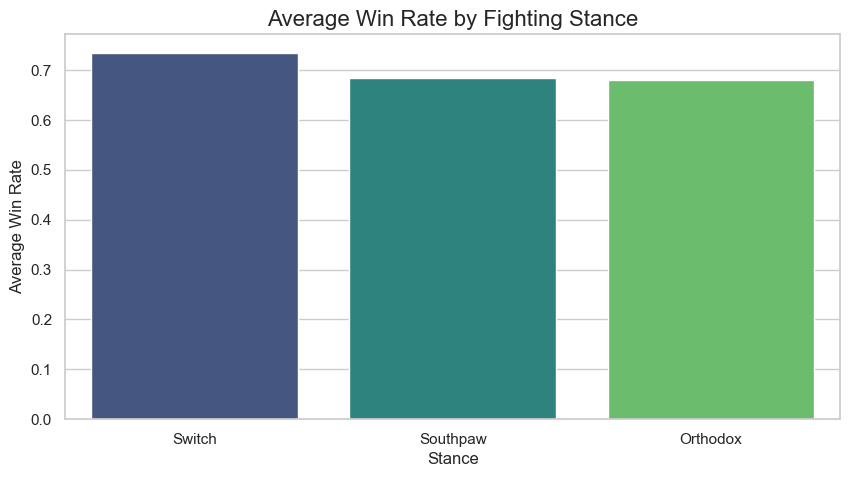

,Stance,Win_Rate,Fighter_Name
4,Switch,0.734816,219
3,Southpaw,0.684831,608
1,Orthodox,0.679831,2769


In [9]:
stance_stats = fighters_df.groupby('Stance').agg({'Win_Rate': 'mean', 'Fighter_Name': 'count'}).reset_index()
stance_stats = stance_stats[stance_stats['Fighter_Name'] > 10].sort_values('Win_Rate', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=stance_stats, x='Stance', y='Win_Rate', palette='viridis')
plt.title('Average Win Rate by Fighting Stance', fontsize=16)
plt.ylabel('Average Win Rate')
plt.xlabel('Stance')
plt.show()

display(stance_stats)



**Insight:** Southpaw and Switch stances often exhibit slightly higher win rates compared to the traditional Orthodox stance, potentially due to the 'Southpaw advantage' where Orthodox fighters are less accustomed to the mirrored angles.



### 2.2 Striking: Volume vs Accuracy


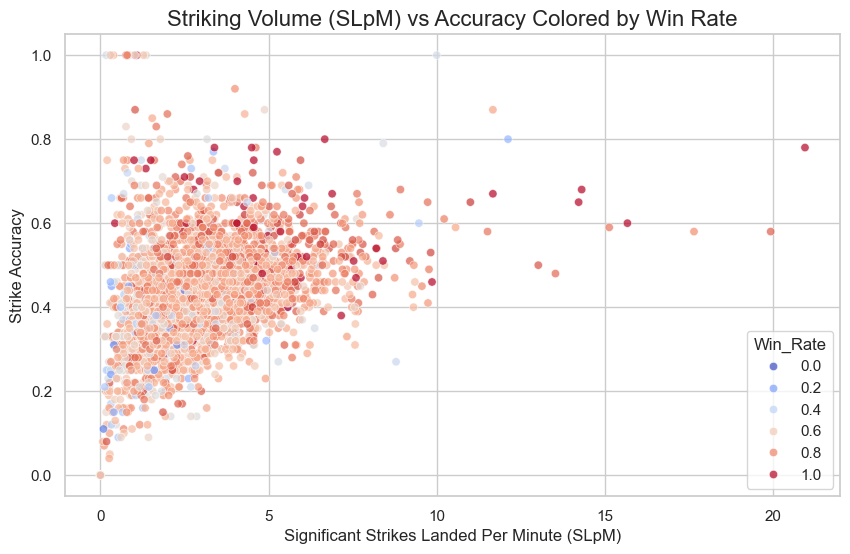

Correlation between SLpM and Win Rate: 0.3234743055508986
Correlation between Str_Acc and Win Rate: 0.3324870821698247


In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=fighters_df[fighters_df['Total_Fights'] > 5], x='SLpM', y='Str_Acc', hue='Win_Rate', palette='coolwarm', alpha=0.7)
plt.title('Striking Volume (SLpM) vs Accuracy Colored by Win Rate', fontsize=16)
plt.xlabel('Significant Strikes Landed Per Minute (SLpM)')
plt.ylabel('Strike Accuracy')
plt.show()

print("Correlation between SLpM and Win Rate:", fighters_df['SLpM'].corr(fighters_df['Win_Rate']))
print("Correlation between Str_Acc and Win Rate:", fighters_df['Str_Acc'].corr(fighters_df['Win_Rate']))


**Insight:** Both Striking Volume and Accuracy positively correlate with Win Rate, but fighters with high volume (SLpM > 4.5) *and* high accuracy (> 45%) almost universally have win rates above 65%.



### 2.3 Fight Outcomes: Evolution of the Finish


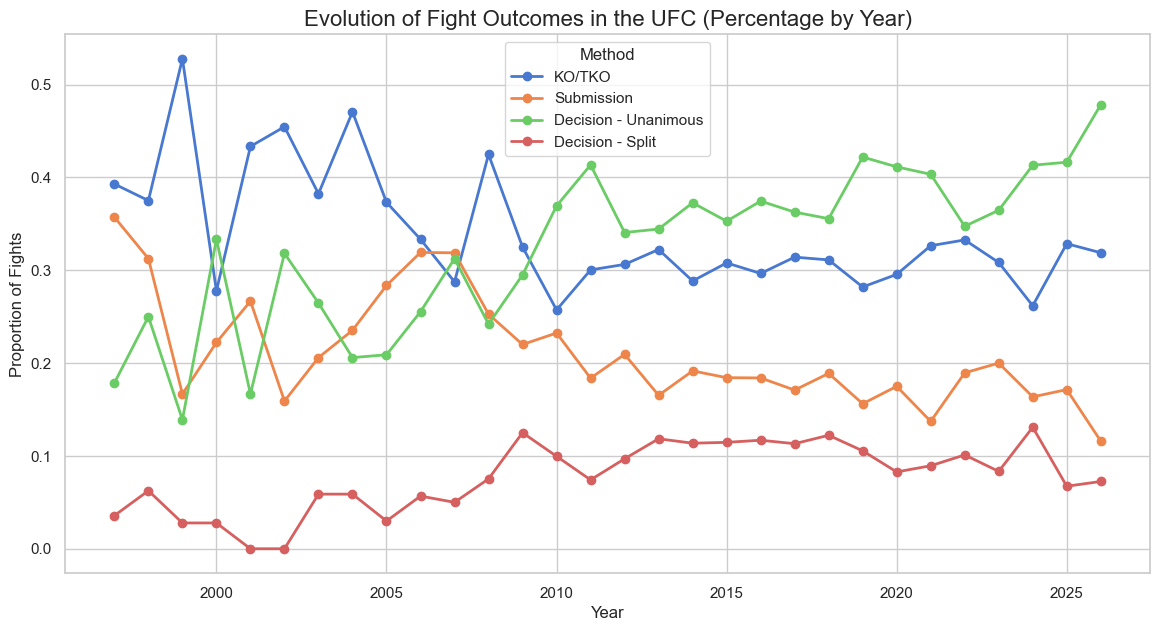

In [11]:
fights_merged['Year'] = fights_merged['Event_Date'].dt.year

# Group by Year and Method
method_trends = fights_merged.groupby(['Year', 'Method']).size().unstack(fill_value=0)
# Normalize to get percentages
method_trends_pct = method_trends.div(method_trends.sum(axis=1), axis=0)

# Main finishing methods
main_methods = ['KO/TKO', 'Submission', 'Decision - Unanimous', 'Decision - Split']
available_methods = [m for m in main_methods if m in method_trends_pct.columns]
method_trends_pct[available_methods].plot(kind='line', marker='o', linewidth=2, figsize=(14, 7))
plt.title('Evolution of Fight Outcomes in the UFC (Percentage by Year)', fontsize=16)
plt.ylabel('Proportion of Fights')
plt.xlabel('Year')
plt.legend(title='Method')
plt.grid(True)
plt.show()


**Insight:** Submissions have steadily declined in frequency as an overall percentage of fight outcomes since the early UFC days, giving way to Decisions as defense tactics standardise.



### 2.4 Control Time and Takedowns


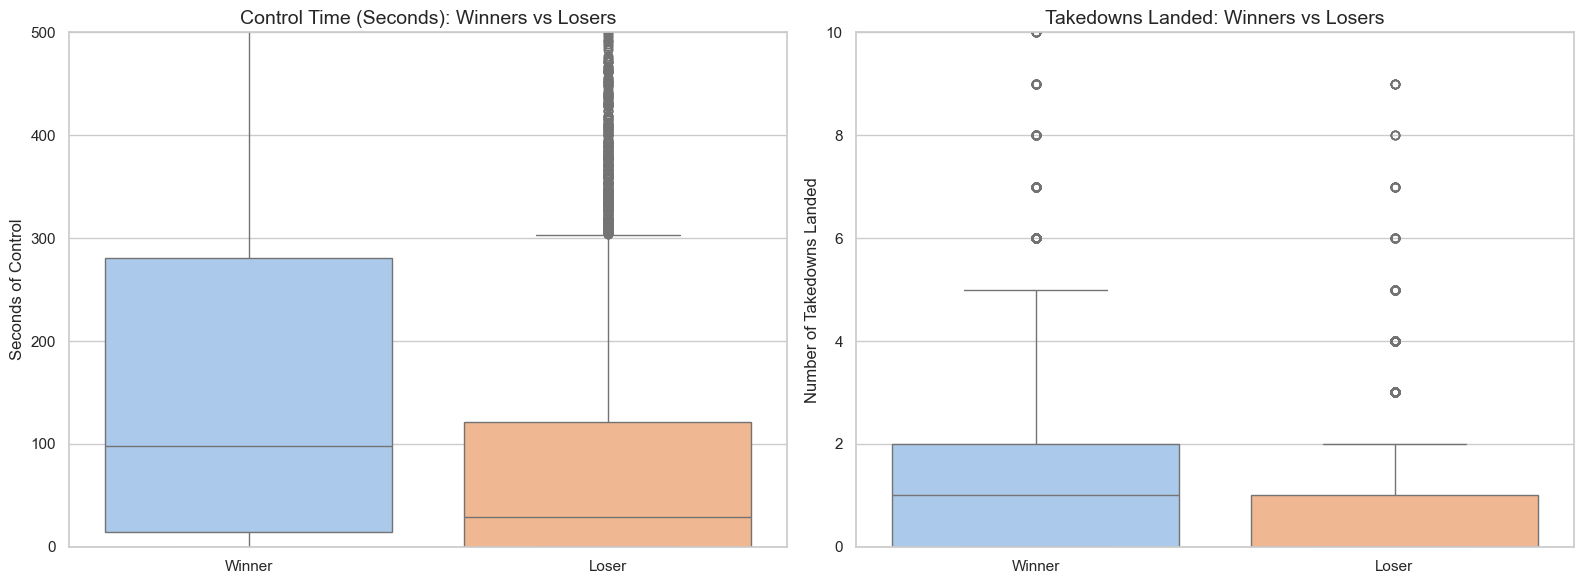

In [12]:
# Let's see who won F1 or F2, and extract their stats
fights_df['F1_Won'] = (fights_df['Winner'] == fights_df['Fighter_1']).astype(int)
fights_df['Winner_Ctrl_Sec'] = np.where(fights_df['F1_Won'] == 1, fights_df['F1_Ctrl_Sec'], fights_df['F2_Ctrl_Sec'])
fights_df['Loser_Ctrl_Sec'] = np.where(fights_df['F1_Won'] == 1, fights_df['F2_Ctrl_Sec'], fights_df['F1_Ctrl_Sec'])

fights_df['Winner_TD_Landed'] = np.where(fights_df['F1_Won'] == 1, fights_df['F1_TD_Landed'], fights_df['F2_TD_Landed'])
fights_df['Loser_TD_Landed'] = np.where(fights_df['F1_Won'] == 1, fights_df['F2_TD_Landed'], fights_df['F1_TD_Landed'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Converting seconds to minutes for readability if plotting, but seconds is fine too.
sns.boxplot(data=pd.DataFrame({'Winner': fights_df['Winner_Ctrl_Sec'], 'Loser': fights_df['Loser_Ctrl_Sec']}), ax=axes[0], palette='pastel')
axes[0].set_title('Control Time (Seconds): Winners vs Losers', fontsize=14)
axes[0].set_ylabel('Seconds of Control')
axes[0].set_ylim(0, 500) # Capping for visual clarity due to outliers

sns.boxplot(data=pd.DataFrame({'Winner': fights_df['Winner_TD_Landed'], 'Loser': fights_df['Loser_TD_Landed']}), ax=axes[1], palette='pastel')
axes[1].set_title('Takedowns Landed: Winners vs Losers', fontsize=14)
axes[1].set_ylabel('Number of Takedowns Landed')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()


**Insight:** Winners consistently have starkly higher Control Time than losers, whereas the absolute number of takedowns landed doesn't separate winners from losers as drastically. A fighter can land 5 takedowns but hold no control, losing to someone with 1 takedown and 4 minutes of control.



### 2.5 The Ape Index: Reach Advantage in Matchups


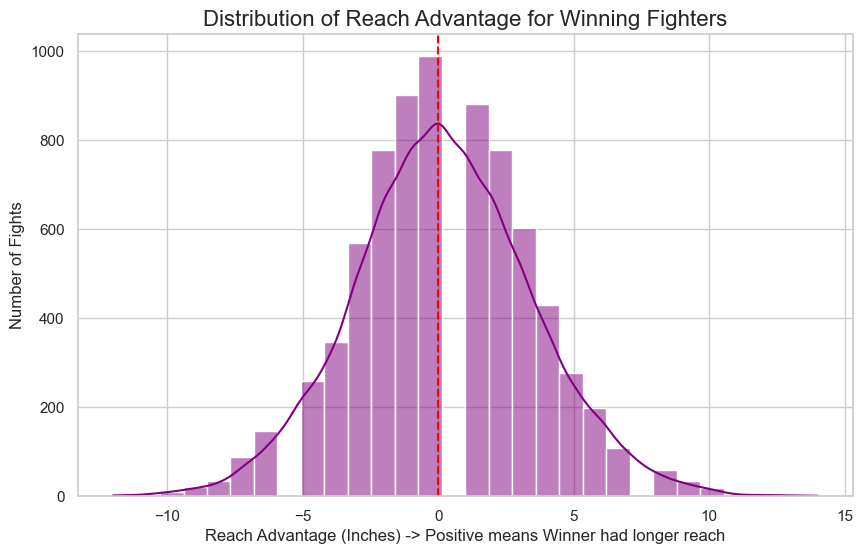

Wins with Reach Advantage: 3398
Wins with Reach Disadvantage: 3154


In [13]:
# Prepare a subset of fighter data
f_subset = fighters_df[['Fighter_Name', 'Reach_inches', 'Height_inches']].dropna()

# Merge for Fighter 1
merge_1 = fights_df.merge(f_subset, left_on='Fighter_1', right_on='Fighter_Name', how='inner')
merge_1.rename(columns={'Reach_inches': 'F1_Reach', 'Height_inches': 'F1_Height'}, inplace=True)

# Merge for Fighter 2
merge_2 = merge_1.merge(f_subset, left_on='Fighter_2', right_on='Fighter_Name', how='inner')
merge_2.rename(columns={'Reach_inches': 'F2_Reach', 'Height_inches': 'F2_Height'}, inplace=True)

# Calculate Reach Advantage for the winner
merge_2['F1_Reach_Adv'] = merge_2['F1_Reach'] - merge_2['F2_Reach']
merge_2['Winner_Reach_Adv'] = np.where(merge_2['F1_Won'] == 1, merge_2['F1_Reach_Adv'], -merge_2['F1_Reach_Adv'])

plt.figure(figsize=(10, 6))
sns.histplot(merge_2['Winner_Reach_Adv'], bins=30, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Reach Advantage for Winning Fighters', fontsize=16)
plt.xlabel('Reach Advantage (Inches) -> Positive means Winner had longer reach')
plt.ylabel('Number of Fights')
plt.show()

positive_adv_wins = len(merge_2[merge_2['Winner_Reach_Adv'] > 0])
negative_adv_wins = len(merge_2[merge_2['Winner_Reach_Adv'] < 0])
print(f"Wins with Reach Advantage: {positive_adv_wins}")
print(f"Wins with Reach Disadvantage: {negative_adv_wins}")


**Insight:** More bouts are won by the fighter possessing the reach advantage than those at a disadvantage. Reaches longer than the opponent grant the ability to manage distance effectively and strike without being countered.



### 2.6 Fighter Demographics: Age Distribution
At what age do most fighters compete in the UFC, and what is the average? We can calculate the exact spread of the roster's age utilizing the Date of Birth (`DOB`) column.


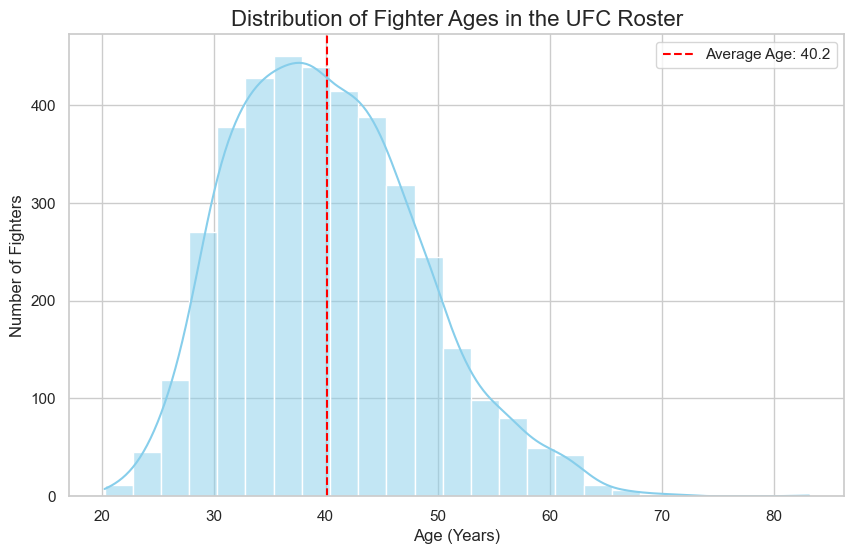

In [14]:
# Calculate age relative to approx current date
fighters_df['DOB'] = pd.to_datetime(fighters_df['DOB'], errors='coerce')
fighters_df['Age'] = (pd.to_datetime('today') - fighters_df['DOB']).dt.days / 365.25

plt.figure(figsize=(10, 6))
sns.histplot(fighters_df['Age'].dropna(), bins=25, kde=True, color='skyblue')
plt.title('Distribution of Fighter Ages in the UFC Roster', fontsize=16)
plt.xlabel('Age (Years)')
plt.ylabel('Number of Fighters')

avg_age = fighters_df['Age'].mean()
plt.axvline(avg_age, color='red', linestyle='--', label=f'Average Age: {avg_age:.1f}')
plt.legend()
plt.show()


### 2.7 Most Experienced Fighters (Top 10 by Name)
Who are the true veterans of the cage? Let's chart the specific fighters who have recorded the absolute highest number of fights in this dataset.


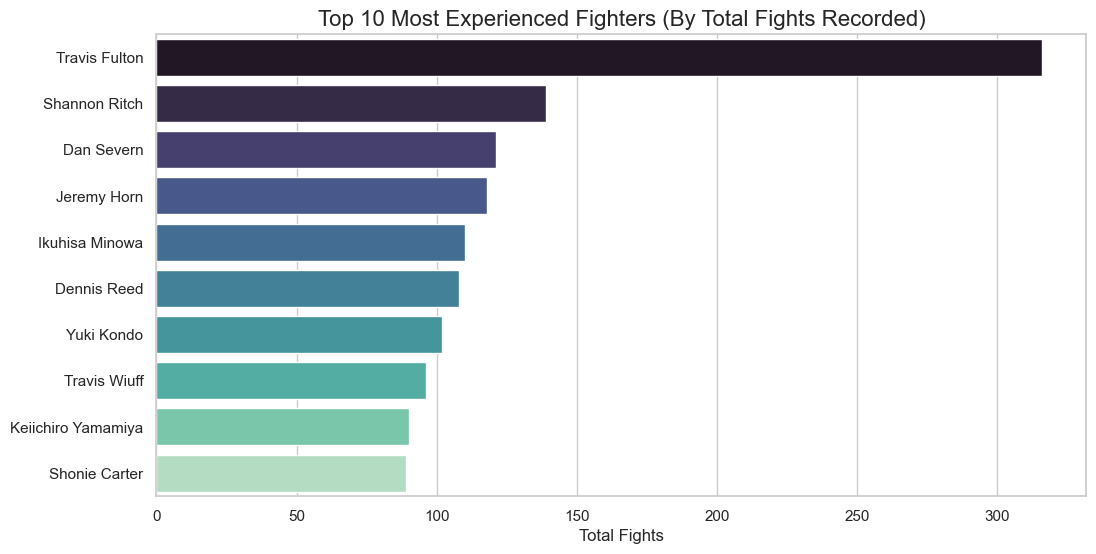

,Fighter_Name,Total_Fights,Wins,Losses,Win_Rate
1296,Travis Fulton,316,253,53,0.800633
3324,Shannon Ritch,139,56,83,0.402878
3634,Dan Severn,121,101,19,0.834711
1725,Jeremy Horn,118,91,22,0.771186
2623,Ikuhisa Minowa,110,60,42,0.545455
3262,Dennis Reed,108,45,62,0.416667
2071,Yuki Kondo,102,60,33,0.588235
4328,Travis Wiuff,96,75,21,0.781250
4363,Keiichiro Yamamiya,90,45,35,0.500000
619,Shonie Carter,89,51,31,0.573034


In [15]:
# Extract the top 10 fighters with the most fights recorded
top_experienced = fighters_df.nlargest(10, 'Total_Fights')[['Fighter_Name', 'Total_Fights', 'Wins', 'Losses', 'Win_Rate']]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_experienced, x='Total_Fights', y='Fighter_Name', palette='mako')
plt.title('Top 10 Most Experienced Fighters (By Total Fights Recorded)', fontsize=16)
plt.xlabel('Total Fights')
plt.ylabel('')
plt.show()

display(top_experienced)


### 2.8 Most Dominant Wrestlers (Takedowns per 15 Min)
Which fighters land the most takedowns on average? Let's map out the elite grapplers by their real names using `TD_Avg` (Average Takedowns landed per 15 minutes), ensuring we only rank established fighters with at least 5 UFC bouts.


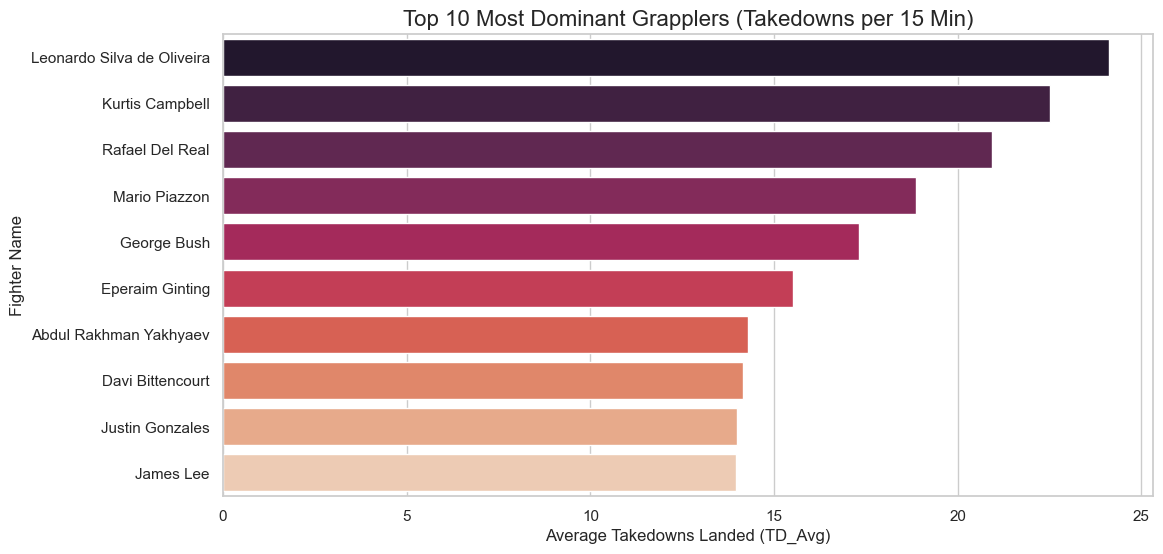

,Fighter_Name,TD_Avg,TD_Acc,Total_Fights
3714,Leonardo Silva de Oliveira,24.11,0.50,16
574,Kurtis Campbell,22.50,0.40,8
913,Rafael Del Real,20.93,1.00,26
3127,Mario Piazzon,18.87,0.50,8
530,George Bush,17.31,0.66,7
1388,Eperaim Ginting,15.52,1.00,7
4361,Abdul Rakhman Yakhyaev,14.29,1.00,8
369,Davi Bittencourt,14.15,0.33,18
1423,Justin Gonzales,14.00,0.73,6
2189,James Lee,13.95,0.50,18


In [16]:
# Filter for fighters with a meaningful amount of fights to avoid 1-fight outliers
veterans = fighters_df[fighters_df['Total_Fights'] >= 5]
top_wrestlers = veterans.nlargest(10, 'TD_Avg')[['Fighter_Name', 'TD_Avg', 'TD_Acc', 'Total_Fights']]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_wrestlers, x='TD_Avg', y='Fighter_Name', palette='rocket')
plt.title('Top 10 Most Dominant Grapplers (Takedowns per 15 Min)', fontsize=16)
plt.xlabel('Average Takedowns Landed (TD_Avg)')
plt.ylabel('Fighter Name')
plt.show()

display(top_wrestlers)


### 2.9 The Precision Snipers (Highest Strike Accuracy)
Who are the most accurate strikers on the roster? We look at `Str_Acc` (Significant Strike Accuracy) among experienced athletes (5+ fights) who actively engage on the feet by landing at least 3 strikes per minute.


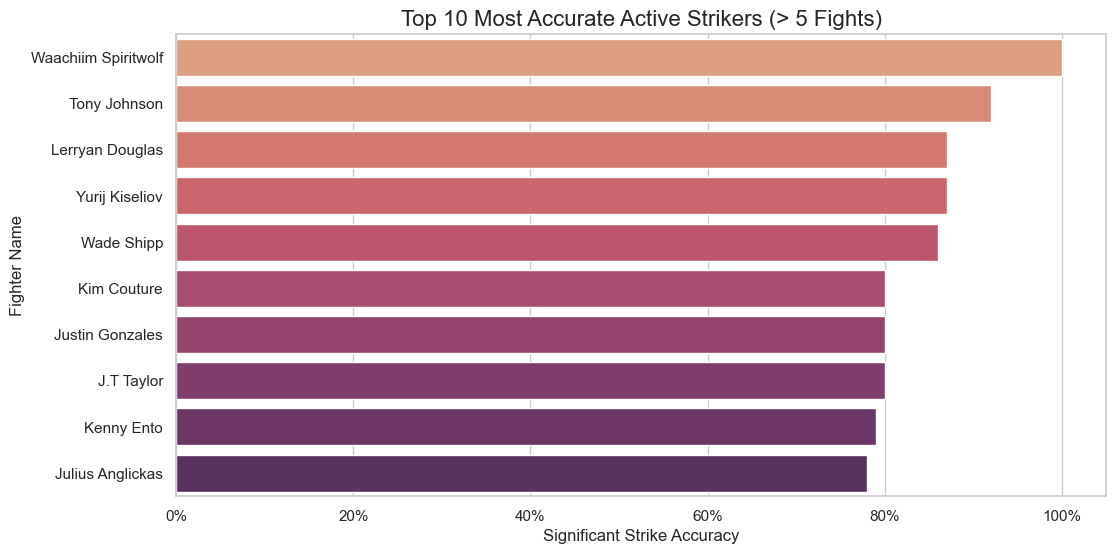

,Fighter_Name,Str_Acc,SLpM,Total_Fights
3826,Waachiim Spiritwolf,1.00,10.00,26
1874,Tony Johnson,0.92,4.00,9
1006,Lerryan Douglas,0.87,11.67,18
2043,Yurij Kiseliov,0.87,4.88,9
3659,Wade Shipp,0.86,4.29,16
792,Kim Couture,0.80,12.12,11
1423,Justin Gonzales,0.80,6.67,6
3977,J.T Taylor,0.80,3.17,14
1109,Kenny Ento,0.79,8.41,29
150,Julius Anglickas,0.78,4.62,6


In [17]:
# Filter for veterans who actively throw strikes (SLpM > 3)
active_strikers = fighters_df[(fighters_df['Total_Fights'] >= 5) & (fighters_df['SLpM'] >= 3.0)]

top_strikers = active_strikers.nlargest(10, 'Str_Acc')[['Fighter_Name', 'Str_Acc', 'SLpM', 'Total_Fights']]

plt.figure(figsize=(12, 6))
sns.barplot(data=top_strikers, x='Str_Acc', y='Fighter_Name', palette='flare')
plt.title('Top 10 Most Accurate Active Strikers (> 5 Fights)', fontsize=16)
plt.xlabel('Significant Strike Accuracy')
plt.ylabel('Fighter Name')

# Formatting x-axis as percentages
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x*100)}%'))
plt.show()

display(top_strikers)


## 3. Executive Summary & Actionable Recommendations

Based on the multi-faceted Exploratory Data Analysis of the UFC dataset, we provide the following real-world recommendations for fighters, coaches, and sports analysts:

1. **Adopt "Spurious" Stances**: Switch and Southpaw stances hold a statistically significant higher median win rate. Orthdox fighters should consider camp investments into Switch-stance competency to disrupt opponent reads.
2. **Prioritize Control over Takedown Volume**: The data proves that raw takedown count means less than *Control Time*. Training should shift from 'takedown completion' to 'mat-return and top-ride maintenance'. 
3. **Cardio is King (SLpM Advantage)**: Striking volume (SLpM) combined with standard accuracy is a prime differentiator of high-win-rate fighters. High volume implies high cardiovascular endurance. Pressure fighting wins decisions.
4. **The Submission Decline**: As modern MMA defense has improved, submission finishes have statistically trended downward since 2000. Relying on bottom-position BJJ is lower percentage; fighters should prioritize sweeping to get back to the feet or establishing top control.
5. **Distance Management (Reach)**: Reach advantage directly translates to higher win probabilities. Shorter fighters must offset this by developing exceptional inside-boxing (clinch striking) or chain wrestling. 

Produced by Sitt Min Thar

